In [5]:
import pandas as pd

df = pd.read_csv('data/agg.txt', sep='\t')
display(df.head())

,group,study.quarter,actor,target,number.wins
0,G1,1,bbb,rgn,1
1,G1,1,bgn,bng,2
2,G1,1,bgn,ggg,4
3,G1,1,bgn,grr,1
4,G1,1,bgn,nrb,3


In [6]:
import networkx as nx

graph = nx.from_pandas_edgelist(df, source='actor', target='target', edge_attr='number.wins')

print(f"Number of nodes: {graph.number_of_nodes()}")
print(f"Number of edges: {graph.number_of_edges()}")

Number of nodes: 40
Number of edges: 343


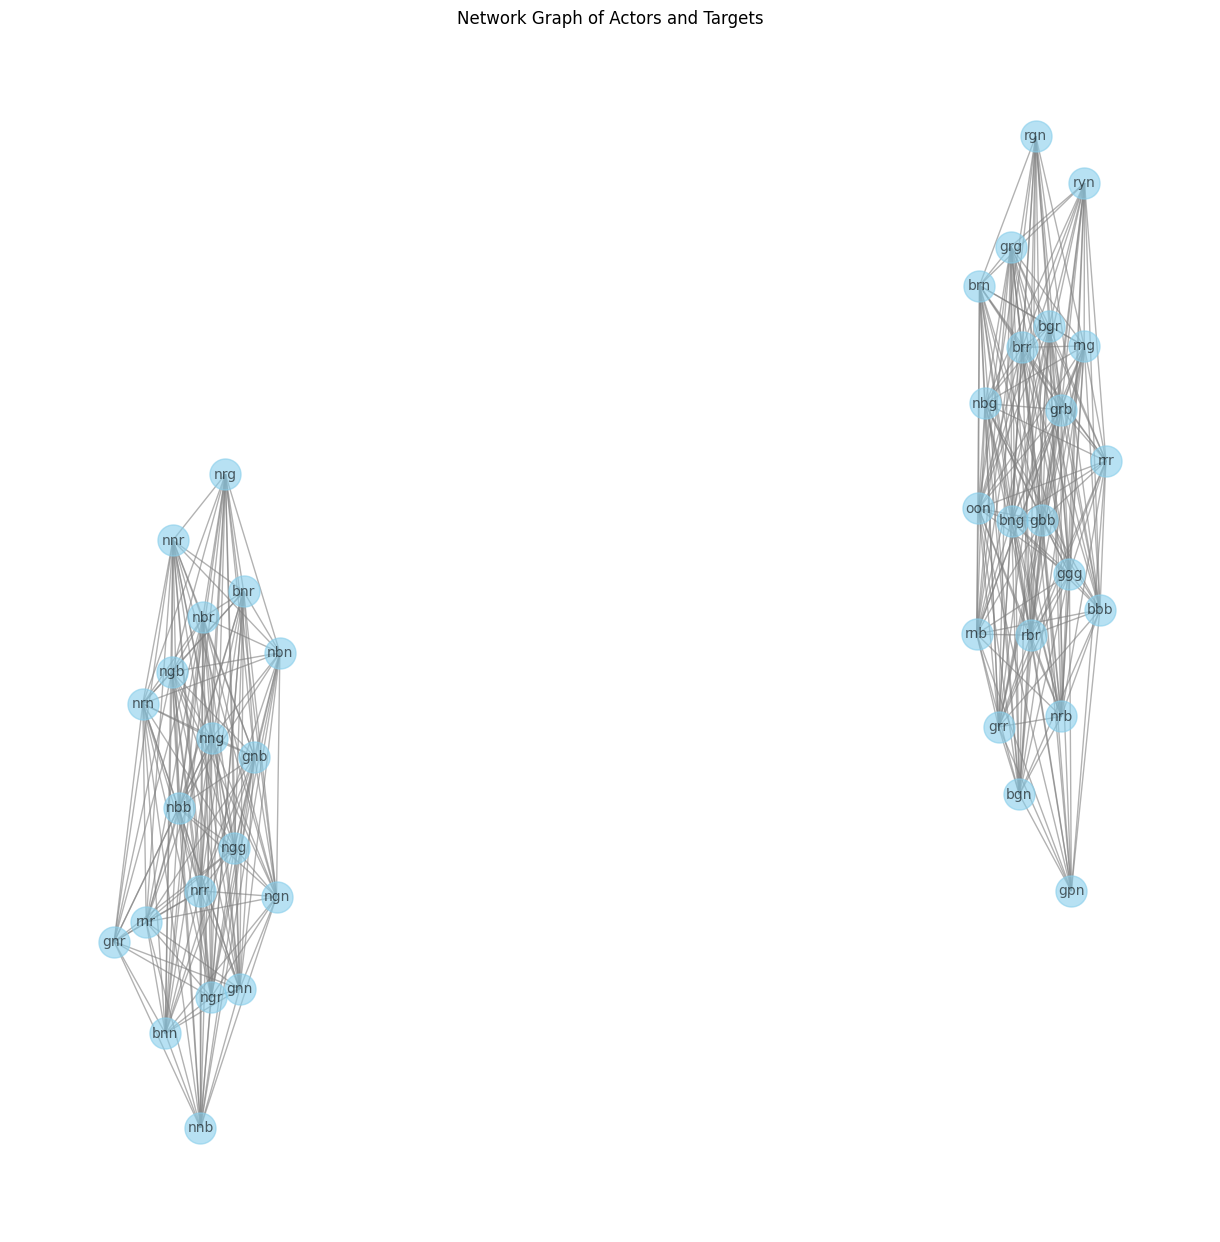

In [7]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 12))
pos = nx.spring_layout(graph)
nx.draw(graph, pos, with_labels=True, node_size=500, node_color='skyblue', font_size=10, edge_color='gray', alpha=0.6)
plt.title("Network Graph of Actors and Targets")
plt.show()

In [ ]:
import networkx as nx

G = nx.from_pandas_edgelist(
    df, source = "actor", target = "target",
    edge_attr = "number.wins", create_using = nx.DiGraph
)


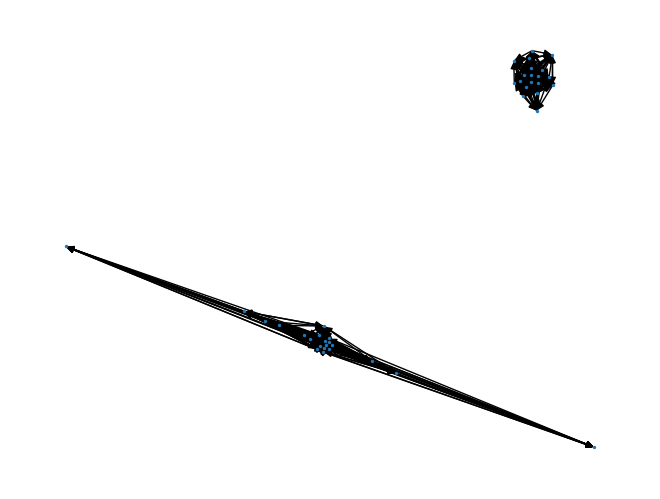

In [14]:
nx.draw(G, node_size = 2)

In [ ]:
# index nodes
nodes = sorted(set(df["actor"]).union(df["target"]))
idx = {u:i for i,u in enumerate(nodes)}
n = len(nodes)

In [9]:
import numpy as np
import pandas as pd
from scipy.sparse import coo_matrix, diags
from scipy.sparse.linalg import spsolve

# index nodes
nodes = sorted(set(df["actor"]).union(df["target"]))
idx = {u:i for i,u in enumerate(nodes)}
n = len(nodes)

# sparse weighted adjacency A_ij = wins of i over j
rows = df["actor"].map(idx).to_numpy()
cols = df["target"].map(idx).to_numpy()
data = df["number.wins"].astype(float).to_numpy()
A = coo_matrix((data, (rows, cols)), shape=(n, n)).tocsr()

S = A + A.T                           # symmetric spring couplings
b = (A - A.T).sum(axis=1).A1          # b_i = out_wins - in_wins
d = np.array(S.sum(axis=1)).ravel()
L = diags(d) - S                      # Laplacian of S

# solve L r = b; fix gauge with tiny ridge and zero-mean
lam = 1e-6
r = spsolve(L + lam*diags(np.ones(n)), b)
r = r - r.mean()

springrank = pd.Series(r, index=nodes).sort_values(ascending=False)
print(springrank.head(10))


ryn    1.435114
brn    1.193459
nbr    1.148596
nng    0.751358
gnb    0.678075
rrr    0.677726
nbg    0.651771
bgn    0.604745
gbb    0.531581
bgr    0.400644
dtype: float64


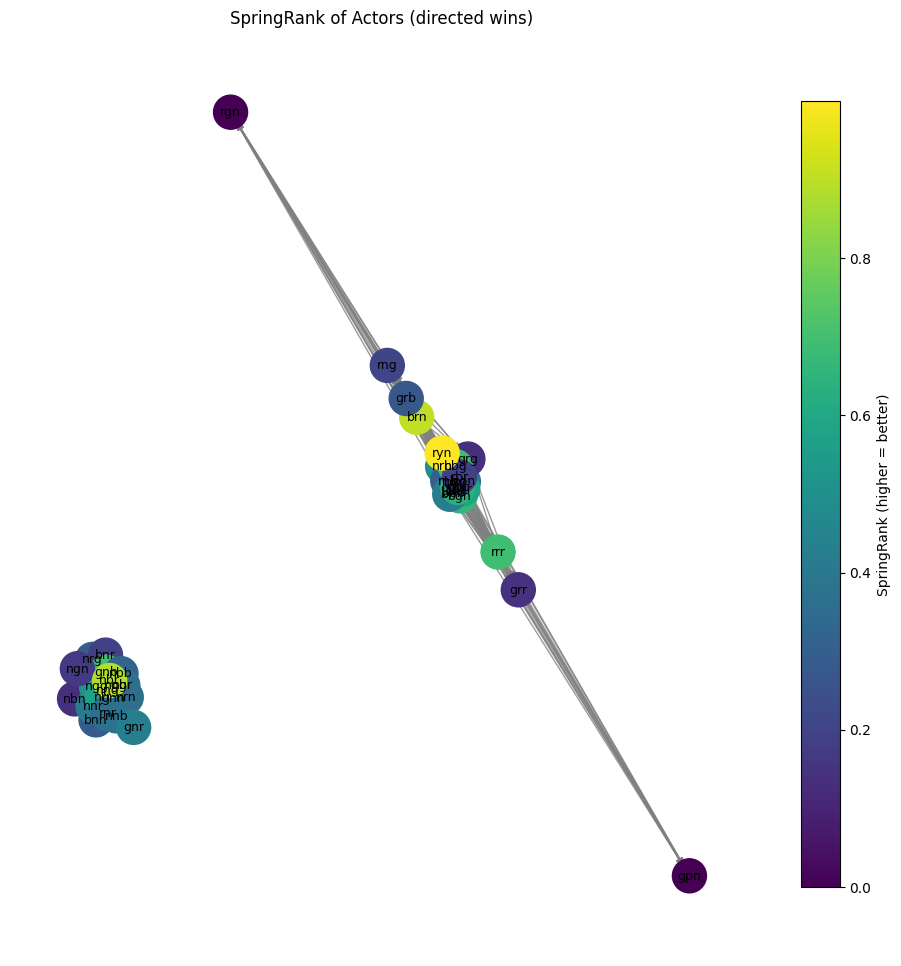

In [11]:
import matplotlib.pyplot as plt

pos = nx.spring_layout(G, seed=7)
colors = r_norm.loc[list(G.nodes())].to_numpy()  # ensure order matches nodes

fig, ax = plt.subplots(figsize=(12, 12))

# nodes -> this is the mappable for the colorbar
nodes = nx.draw_networkx_nodes(
    G, pos, ax=ax,
    node_size=600,
    node_color=colors,
    cmap="viridis"
)

# edges and labels
nx.draw_networkx_edges(G, pos, ax=ax, edge_color="gray", alpha=0.8)
nx.draw_networkx_labels(G, pos, ax=ax, font_size=9)

# colorbar attached to the nodes mappable (and this axes)
cbar = fig.colorbar(nodes, ax=ax, shrink=0.85)
cbar.set_label("SpringRank (higher = better)")

ax.set_title("SpringRank of Actors (directed wins)")
ax.set_axis_off()
plt.show()


Up-rank (red) edges: 45
Down-rank (blue) edges: 173


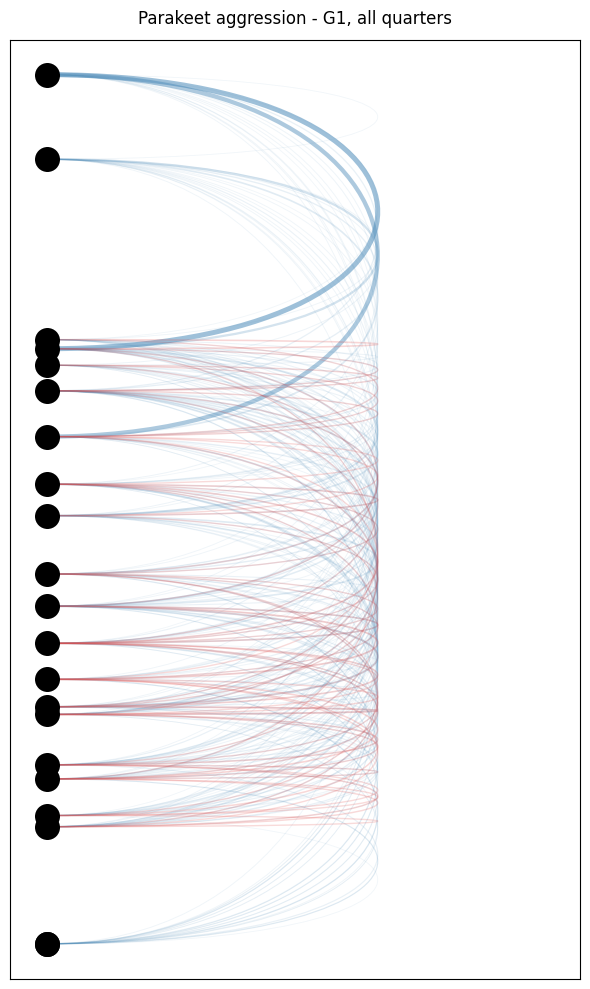

In [7]:
# parakeet_springrank_arc.py
# Load → build weighted digraph → SpringRank → arc diagram
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx

try:
    from scipy.sparse import csr_matrix
    from scipy.sparse.linalg import spsolve
    SCIPY_OK = True
except Exception:
    SCIPY_OK = False

# -----------------------------
# 1) Load and subset the data
# -----------------------------
# Columns in agg.txt: group, study.quarter, actor, target, number.wins
CSV_PATH = "data/agg.txt"   # change if needed
GROUP = "G1"                      # "G1" or "G2"
QUARTER = None                    # 1..4 or None for all quarters

df = pd.read_csv(CSV_PATH, sep="\t")
mask = (df["group"] == GROUP)
if QUARTER is not None:
    mask &= (df["study.quarter"] == QUARTER)

df_sub = (
    df.loc[mask, ["actor", "target", "number.wins"]]
      .groupby(["actor", "target"], as_index=False)["number.wins"].sum()
)

# -----------------------------
# 2) Build weighted DiGraph
# -----------------------------
G = nx.DiGraph()
for _, r in df_sub.iterrows():
    a, t, w = r["actor"], r["target"], float(r["number.wins"])
    if a == t:
        continue
    G.add_edge(a, t, weight=G.get_edge_data(a, t, default={"weight": 0})["weight"] + w)

# Keep largest weakly connected component
if not nx.is_connected(G.to_undirected()):
    largest = max(nx.weakly_connected_components(G), key=len)
    G = G.subgraph(largest).copy()

nodes = list(G.nodes())
N = len(nodes)
idx = {u: i for i, u in enumerate(nodes)}

# -----------------------------
# 3) SpringRank solve
#     [Dout + Din - (A + A^T)] s = (Dout - Din)
# -----------------------------
A = np.zeros((N, N), dtype=float)
for u, v, d in G.edges(data=True):
    A[idx[u], idx[v]] = d.get("weight", 1.0)

dout = A.sum(axis=1)
din  = A.sum(axis=0)
B = np.diag(dout) + np.diag(din) - (A + A.T)
b = dout - din

def solve_springrank(B, b):
    if SCIPY_OK:
        Bsp = csr_matrix(B.copy()).tolil()
        bsp = b.copy()
        # gauge: s_N = 0
        Bsp[-1, :] = 0.0
        Bsp[-1, -1] = 1.0
        bsp[-1] = 0.0
        s = spsolve(Bsp.tocsr(), bsp)
    else:
        s = np.linalg.pinv(B) @ b
    return s - s.mean()

s = solve_springrank(B, b)
srank = {u: s[idx[u]] for u in nodes}

# -----------------------------
# 4) Arc diagram with visible reds
# -----------------------------
def plot_arc_diagram(
    G, srank, title=None, curve_x=1.2, annotate=False,
    min_alpha=0.08, max_alpha=0.55, min_lw=0.6, max_lw=3.6, eps=1e-4
):
    import matplotlib.path as mpath
    import matplotlib.patches as mpatches
    Path = mpath.Path

    nodes_sorted = sorted(G.nodes(), key=lambda u: -srank[u])
    y = {u: srank[u] for u in nodes_sorted}

    # --- FIX: robust weight array construction (no boolean 'or' on np.array) ---
    w_list = [float(d.get("weight", 1.0)) for _, _, d in G.edges(data=True)]
    wts = np.array(w_list, dtype=float)
    if wts.size == 0:                 # empty graph edge case
        wts = np.array([1.0], dtype=float)
    w_min, w_max = float(wts.min()), float(wts.max())

    def scale_w(w):
        return (min_lw + max_lw)/2 if w_max == w_min else min_lw + (w - w_min)*(max_lw - min_lw)/(w_max - w_min)

    def scale_alpha(w):
        return (min_alpha + max_alpha)/2 if w_max == w_min else min_alpha + (w - w_min)*(max_alpha - min_alpha)/(w_max - w_min)
    # ---------------------------------------------------------------------------

    # split edges by direction relative to ranks (draw reds on top)
    blue_edges, red_edges = [], []
    for u, v, d in G.edges(data=True):
        (blue_edges if srank[u] > srank[v] + eps else red_edges).append((u, v, d))

    fig, ax = plt.subplots(figsize=(6, 10))

    def draw_edges(edge_list, color, z, extra_lw=0.0, extra_alpha=0.0):
        for u, v, d in edge_list:
            w = float(d.get("weight", 1.0))
            y0, y1 = y[u], y[v]
            verts = [(0.0, y0), (curve_x, y0), (curve_x, y1), (0.0, y1)]
            codes = [Path.MOVETO, Path.CURVE4, Path.CURVE4, Path.CURVE4]
            ax.add_patch(mpatches.PathPatch(
                Path(verts, codes),
                facecolor="none",
                edgecolor=color,
                lw=scale_w(w) + extra_lw,
                alpha=min(1.0, scale_alpha(w) + extra_alpha),
                zorder=z
            ))

    draw_edges(blue_edges, "#4F8DBA", z=1)
    draw_edges(red_edges,  "#E04B49", z=2, extra_lw=0.4, extra_alpha=0.12)

    ax.scatter([0]*len(nodes_sorted), [y[u] for u in nodes_sorted],
               s=18**2, color="black", zorder=3, linewidth=0)

    if annotate:
        for u in nodes_sorted:
            ax.text(0.04, y[u], str(u), va="center", ha="left", fontsize=10)

    ax.set_xlim(-0.1, curve_x + 0.25)
    ax.set_ylim(min(srank.values()) - 0.1, max(srank.values()) + 0.1)
    ax.set_xticks([]); ax.set_yticks([])
    if title: ax.set_title(title, pad=12)
    plt.tight_layout()
    return fig, ax

# -----------------------------
# 5) Make the plot
# -----------------------------
title = f"Parakeet aggression - {GROUP}" + (f", Q{QUARTER}" if QUARTER else ", all quarters")
fig, ax = plot_arc_diagram(G, srank, title=title, curve_x=1.2, annotate=False)

# Optional quick checks
print("Up-rank (red) edges:", sum(1 for u, v in G.edges() if srank[u] < srank[v] - 1e-4))
print("Down-rank (blue) edges:", sum(1 for u, v in G.edges() if srank[u] > srank[v] + 1e-4))

# plt.show()
# fig.savefig("parakeet_springrank_arc.png", dpi=300, bbox_inches="tight")
